In [1]:
import pandas as pd

In [2]:
df=pd.read_excel('/content/sample_data/premiums (1).xlsx')

In [3]:
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490


In [4]:
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Region,0
Marital_status,0
Number Of Dependants,0
BMI_Category,0
Smoking_Status,11
Employment_Status,2
Income_Level,13
Income_Lakhs,0


In [6]:
df['Smoking_Status']=df['Smoking_Status'].fillna(df['Smoking_Status'].mode()[0])

In [7]:
df['Employment_Status']=df['Employment_Status'].fillna(df['Employment_Status'].mode()[0])
df['Income_Level']=df['Income_Level'].fillna(df['Income_Level'].mode()[0])

In [8]:
df.isnull().sum()

,0
Age,0
Gender,0
Region,0
Marital_status,0
Number Of Dependants,0
BMI_Category,0
Smoking_Status,0
Employment_Status,0
Income_Level,0
Income_Lakhs,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(50000, 13)

In [11]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [12]:
df[df['Number Of Dependants']<0]['Number Of Dependants'].unique()

array([-3, -1])

In [13]:
df['Number Of Dependants']=df['Number Of Dependants'].abs()

In [14]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.717520,23.018200,15768.116320
std,15.000437,1.492009,24.219197,8419.839675
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [15]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns

Index(['Age', 'Number Of Dependants', 'Income_Lakhs', 'Annual_Premium_Amount'], dtype='object')

In [16]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

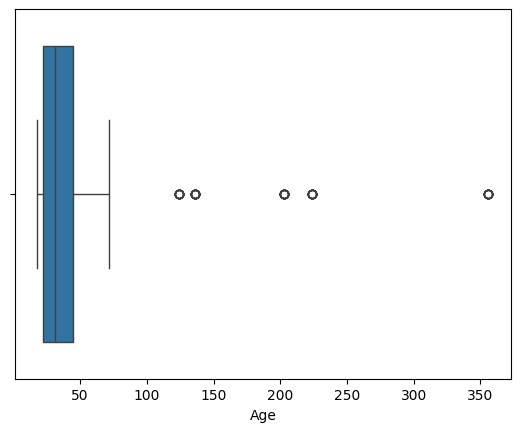

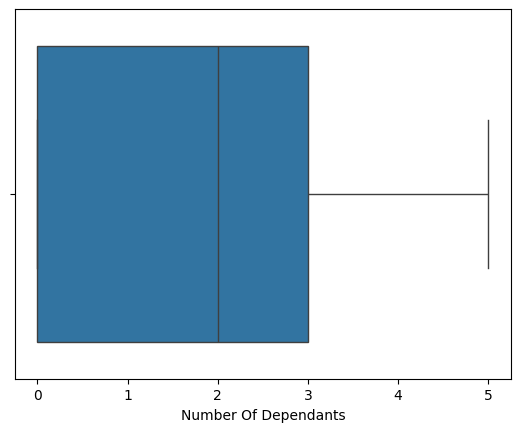

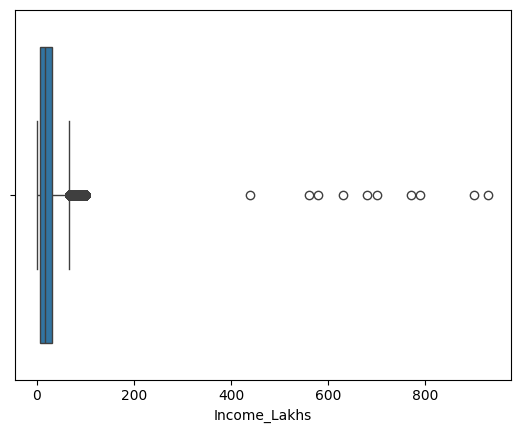

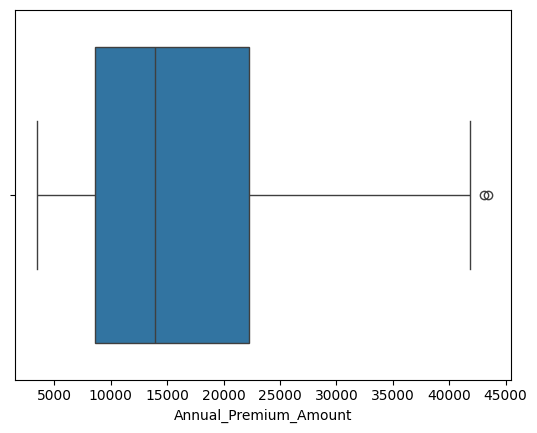

In [17]:
for col in numeric_columns:
  sns.boxplot(x=df[col])
  plt.show()

OUTLIER TREATMENT:AGE COULMN

In [18]:
df[df['Age']>100]['Age'].unique()

array([224, 124, 136, 203, 356])

In [19]:
df1=df[df.Age<=100]
df1.Age.describe()


,Age
count,49942.000000
mean,34.403648
std,13.682354
min,18.000000
25%,22.000000
50%,31.000000
75%,45.000000
max,72.000000


INCOME COLUMN

In [20]:
Q1=df1['Income_Lakhs'].quantile(0.25)
Q3=df1['Income_Lakhs'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [21]:
lower_bound,upper_bound

(np.float64(-29.0), np.float64(67.0))

In [22]:
df1[df1.Income_Lakhs>upper_bound].shape

(3560, 13)

In [23]:
quantile_threshold=df1.Income_Lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [24]:
df1[df1.Income_Lakhs>quantile_threshold].shape

(10, 13)

In [25]:
df2=df1[df1.Income_Lakhs<quantile_threshold].copy()
df2.shape

(49832, 13)

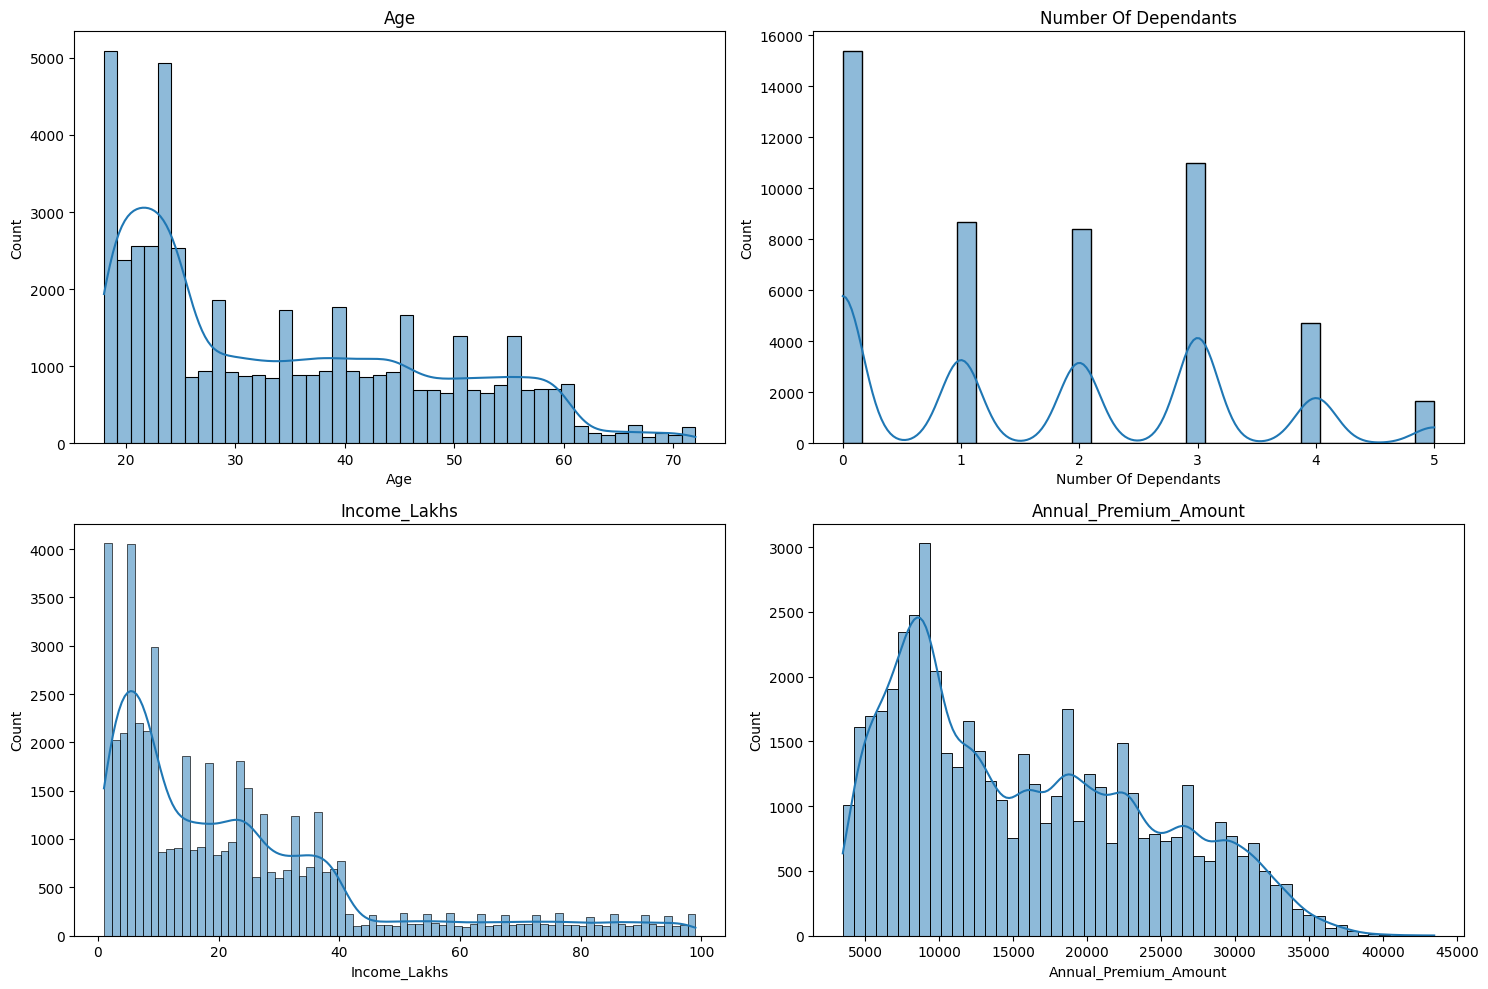

In [26]:
fig,axs=plt.subplots(nrows=2,ncols=2,figsize=(15,10))
for i, column in enumerate(numeric_columns):
  ax=axs[i//2,i%2]
  sns.histplot(df2[column],kde=True,ax=ax)
  ax.set_title(column)
plt.tight_layout()
plt.show()

In [27]:
df2.head(2)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


In [28]:
numeric_columns

Index(['Age', 'Number Of Dependants', 'Income_Lakhs', 'Annual_Premium_Amount'], dtype='object')

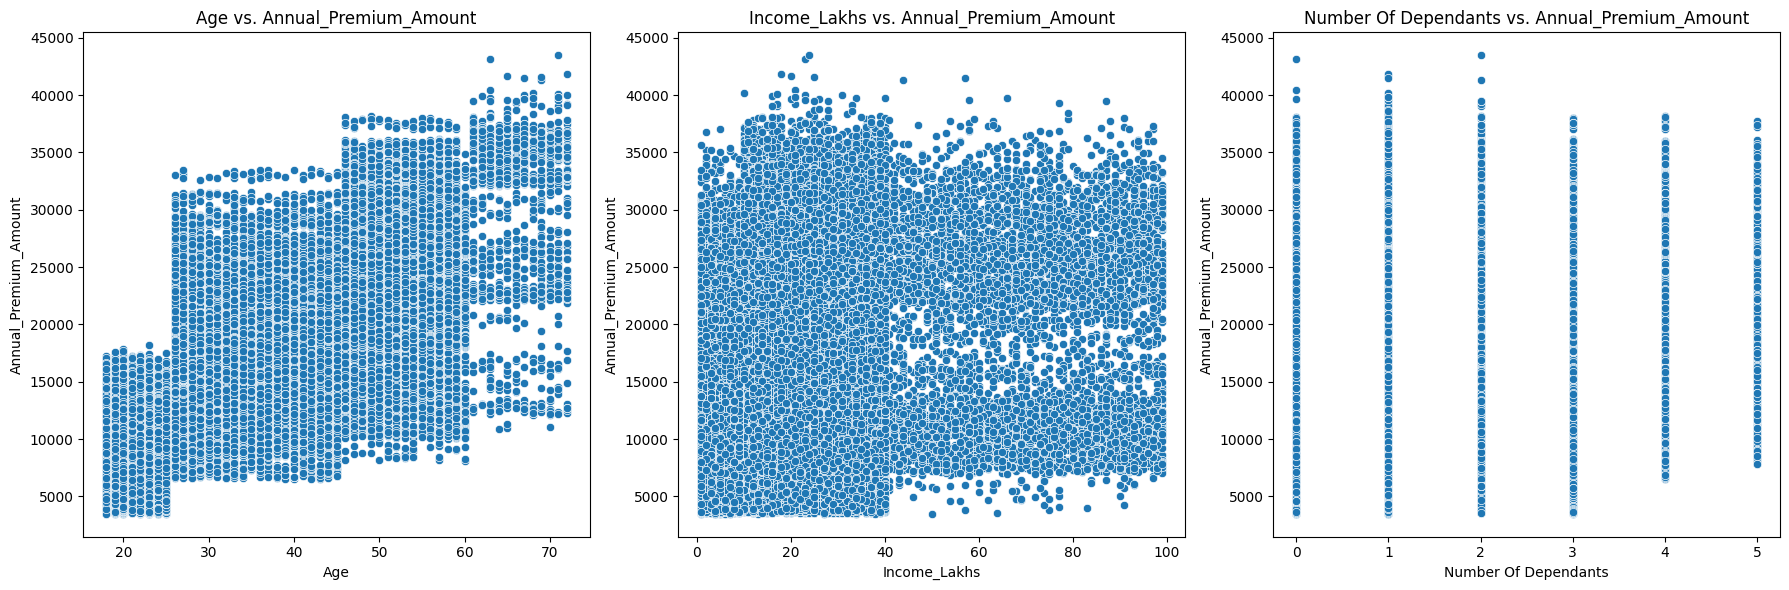

In [29]:
numeric_features = ['Age', 'Income_Lakhs', 'Number Of Dependants']
fig, axs = plt.subplots(1, len(numeric_features), figsize=(18, 6))
for ax, column in zip(axs, numeric_features):
  sns.scatterplot(x=df2[column], y=df2['Annual_Premium_Amount'], ax=ax)
  ax.set_title(f"{column} vs. Annual_Premium_Amount")
  ax.set_xlabel(column)
  ax.set_ylabel('Annual_Premium_Amount')
plt.tight_layout()
plt.show()

In [30]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [31]:
categorical_cols=['Gender', 'Region', 'Marital_status','BMI_Category', 'Smoking_Status', 'Employment_Status', 'Medical History', 'Insurance_Plan','Income_Level']
for col in categorical_cols:
  print(col,":",df2[col].unique())

Gender : ['Male' 'Female']
Region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
Marital_status : ['Unmarried' 'Married']
BMI_Category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
Smoking_Status : ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
Employment_Status : ['Salaried' 'Self-Employed' 'Freelancer']
Medical History : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
Insurance_Plan : ['Bronze' 'Silver' 'Gold']
Income_Level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']


In [32]:
df2['Smoking_Status'].replace({'Smoking=0':'No Smoking','Does Not Smoke':'No Smoking','Not Smoking':'No Smoking'},inplace=True)
df2['Smoking_Status'].unique()

/tmp/ipykernel_3716/940555701.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Smoking_Status'].replace({'Smoking=0':'No Smoking','Does Not Smoke':'No Smoking','Not Smoking':'No Smoking'},inplace=True)


array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [33]:
df2.head(2)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


In [34]:
pct_count=df2['Gender'].value_counts(normalize=True)*100
pct_count

,proportion
Gender,
Male,54.950634
Female,45.049366


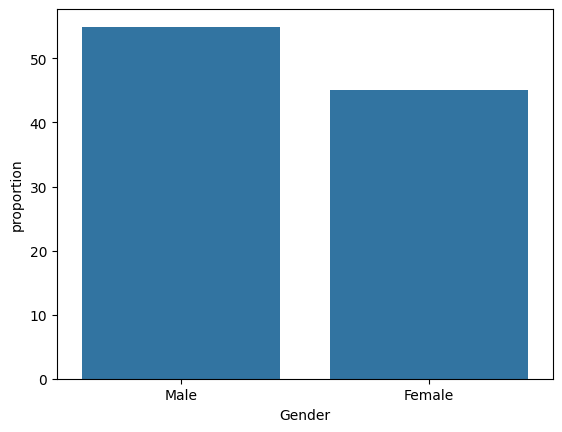

In [35]:
sns.barplot(x=pct_count.index,y=pct_count)
plt.show()

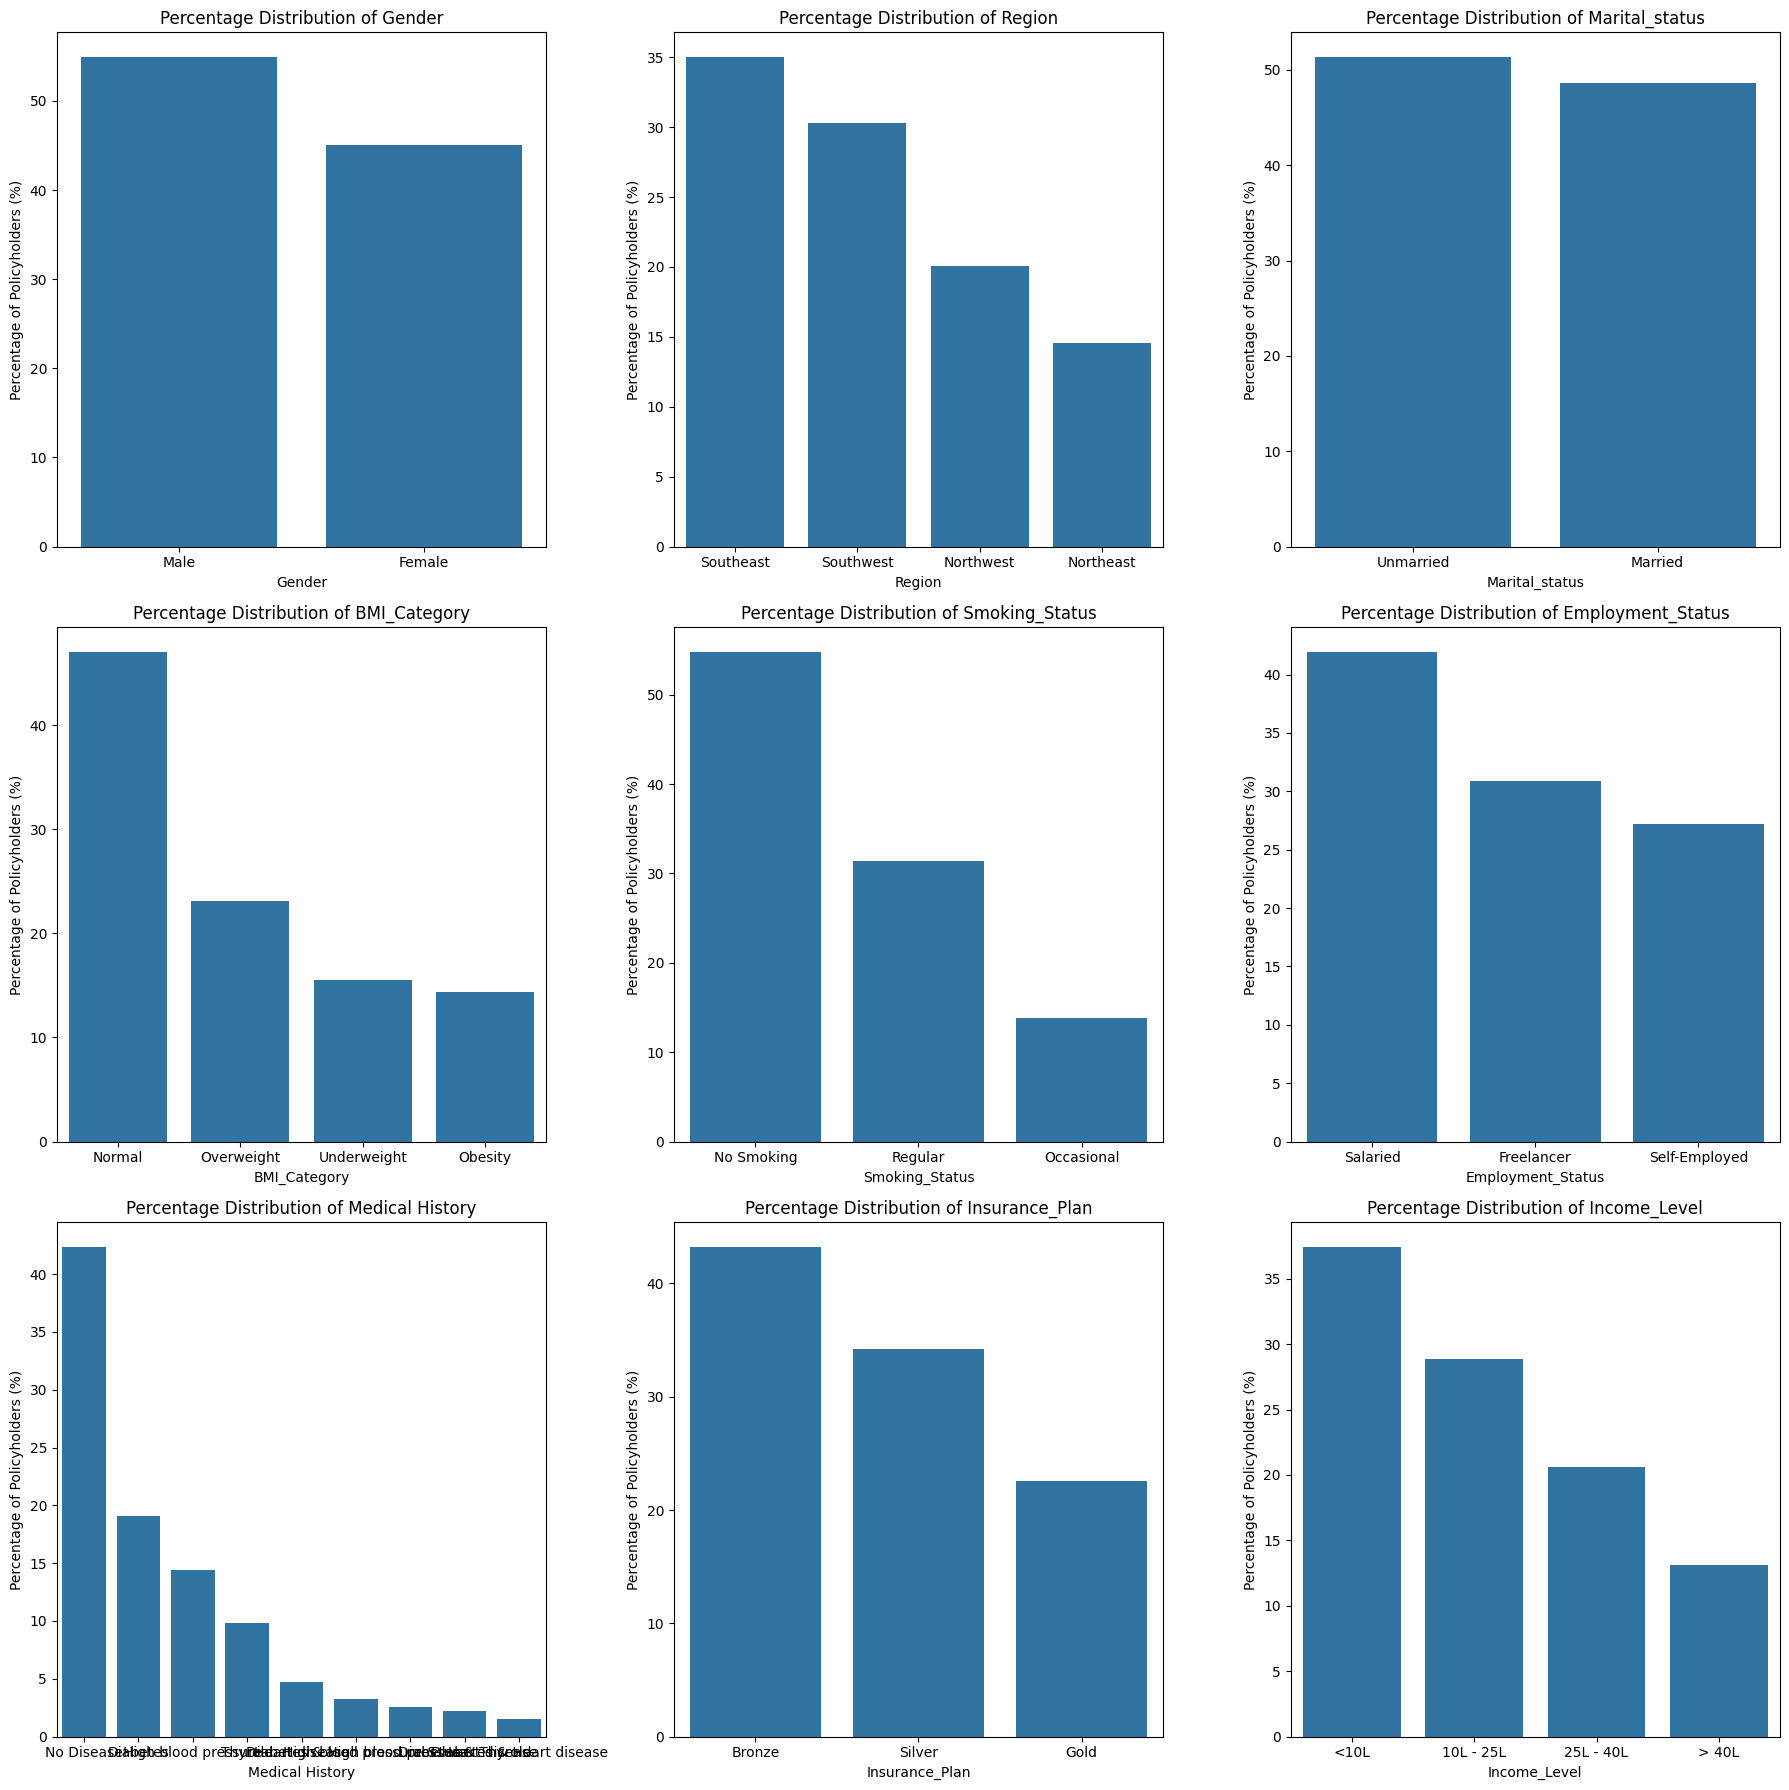

In [36]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies

    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

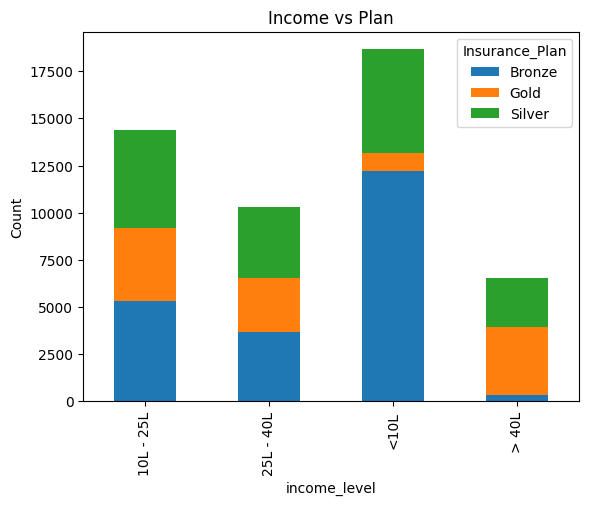

In [37]:
crosstab = pd.crosstab(df2['Income_Level'], df2['Insurance_Plan'])

crosstab.plot(kind='bar', stacked=True)

plt.title('Income vs Plan')
plt.xlabel('income_level')
plt.ylabel('Count')
plt.show()

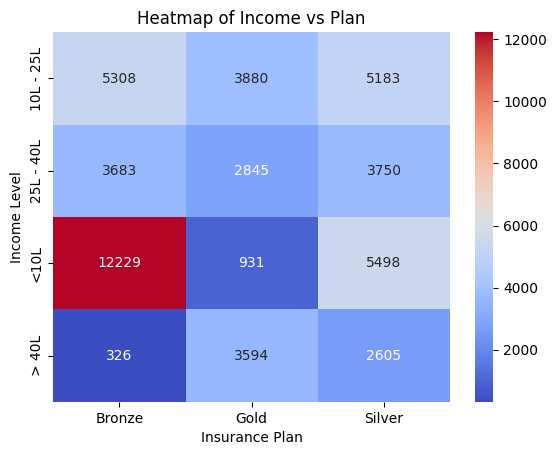

In [38]:
# Cross-tabulation of income level and insurance plan


# Heatmap
sns.heatmap(crosstab, annot=True, cmap='coolwarm', fmt='d')

plt.title('Heatmap of Income vs Plan')
plt.xlabel('Insurance Plan')
plt.ylabel('Income Level')
plt.show()

In [39]:
df.head(2)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


In [40]:
# Define the risk scores for each condition
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[['disease1', 'disease2']] = df2['Medical History'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2['disease1'].fillna('none', inplace=True)
df2['disease2'].fillna('none', inplace=True)
df2['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)

# Normalize the risk score to a range of 0 to 1
max_score = df2['total_risk_score'].max()
min_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_score) / (max_score - min_score)
df2.head(2)

/tmp/ipykernel_3716/2752006182.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['disease1'].fillna('none', inplace=True)
/tmp/ipykernel_3716/2752006182.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571


In [41]:
df2['Insurance_Plan'] = df2['Insurance_Plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [42]:
df2.Income_Level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [43]:
# Check if mapping is already applied to avoid converting valid values to NaN
if df2['Income_Level'].dtype == 'object':
    df2['Income_Level'] = df2['Income_Level'].map({'<10L': 1, '10L - 25L': 2, '25L - 40L': 3, '> 40L': 4})

In [44]:
nominal_cols = ['Gender', 'Region', 'Marital_status', 'BMI_Category', 'Smoking_Status', 'Employment_Status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(3)

,Age,Number Of Dependants,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,disease1,disease2,total_risk_score,...,Region_Southeast,Region_Southwest,Marital_status_Unmarried,BMI_Category_Obesity,BMI_Category_Overweight,BMI_Category_Underweight,Smoking_Status_Occasional,Smoking_Status_Regular,Employment_Status_Salaried,Employment_Status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1


In [45]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49832 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              49832 non-null  int64  
 1   Number Of Dependants             49832 non-null  int64  
 2   Income_Level                     49832 non-null  int64  
 3   Income_Lakhs                     49832 non-null  int64  
 4   Medical History                  49832 non-null  object 
 5   Insurance_Plan                   49832 non-null  int64  
 6   Annual_Premium_Amount            49832 non-null  int64  
 7   disease1                         49832 non-null  object 
 8   disease2                         49832 non-null  object 
 9   total_risk_score                 49832 non-null  int64  
 10  normalized_risk_score            49832 non-null  float64
 11  Gender_Male                      49832 non-null  int64  
 12  Region_Northwest       

In [46]:
df4=df3.drop(['Medical History','disease1','disease2','total_risk_score'],axis=1)
df4.head(4)


,Age,Number Of Dependants,Income_Level,Income_Lakhs,Insurance_Plan,Annual_Premium_Amount,normalized_risk_score,Gender_Male,Region_Northwest,Region_Southeast,Region_Southwest,Marital_status_Unmarried,BMI_Category_Obesity,BMI_Category_Overweight,BMI_Category_Underweight,Smoking_Status_Occasional,Smoking_Status_Regular,Employment_Status_Salaried,Employment_Status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0


In [47]:
df4.columns

Index(['Age', 'Number Of Dependants', 'Income_Level', 'Income_Lakhs',
       'Insurance_Plan', 'Annual_Premium_Amount', 'normalized_risk_score',
       'Gender_Male', 'Region_Northwest', 'Region_Southeast',
       'Region_Southwest', 'Marital_status_Unmarried', 'BMI_Category_Obesity',
       'BMI_Category_Overweight', 'BMI_Category_Underweight',
       'Smoking_Status_Occasional', 'Smoking_Status_Regular',
       'Employment_Status_Salaried', 'Employment_Status_Self-Employed'],
      dtype='object')

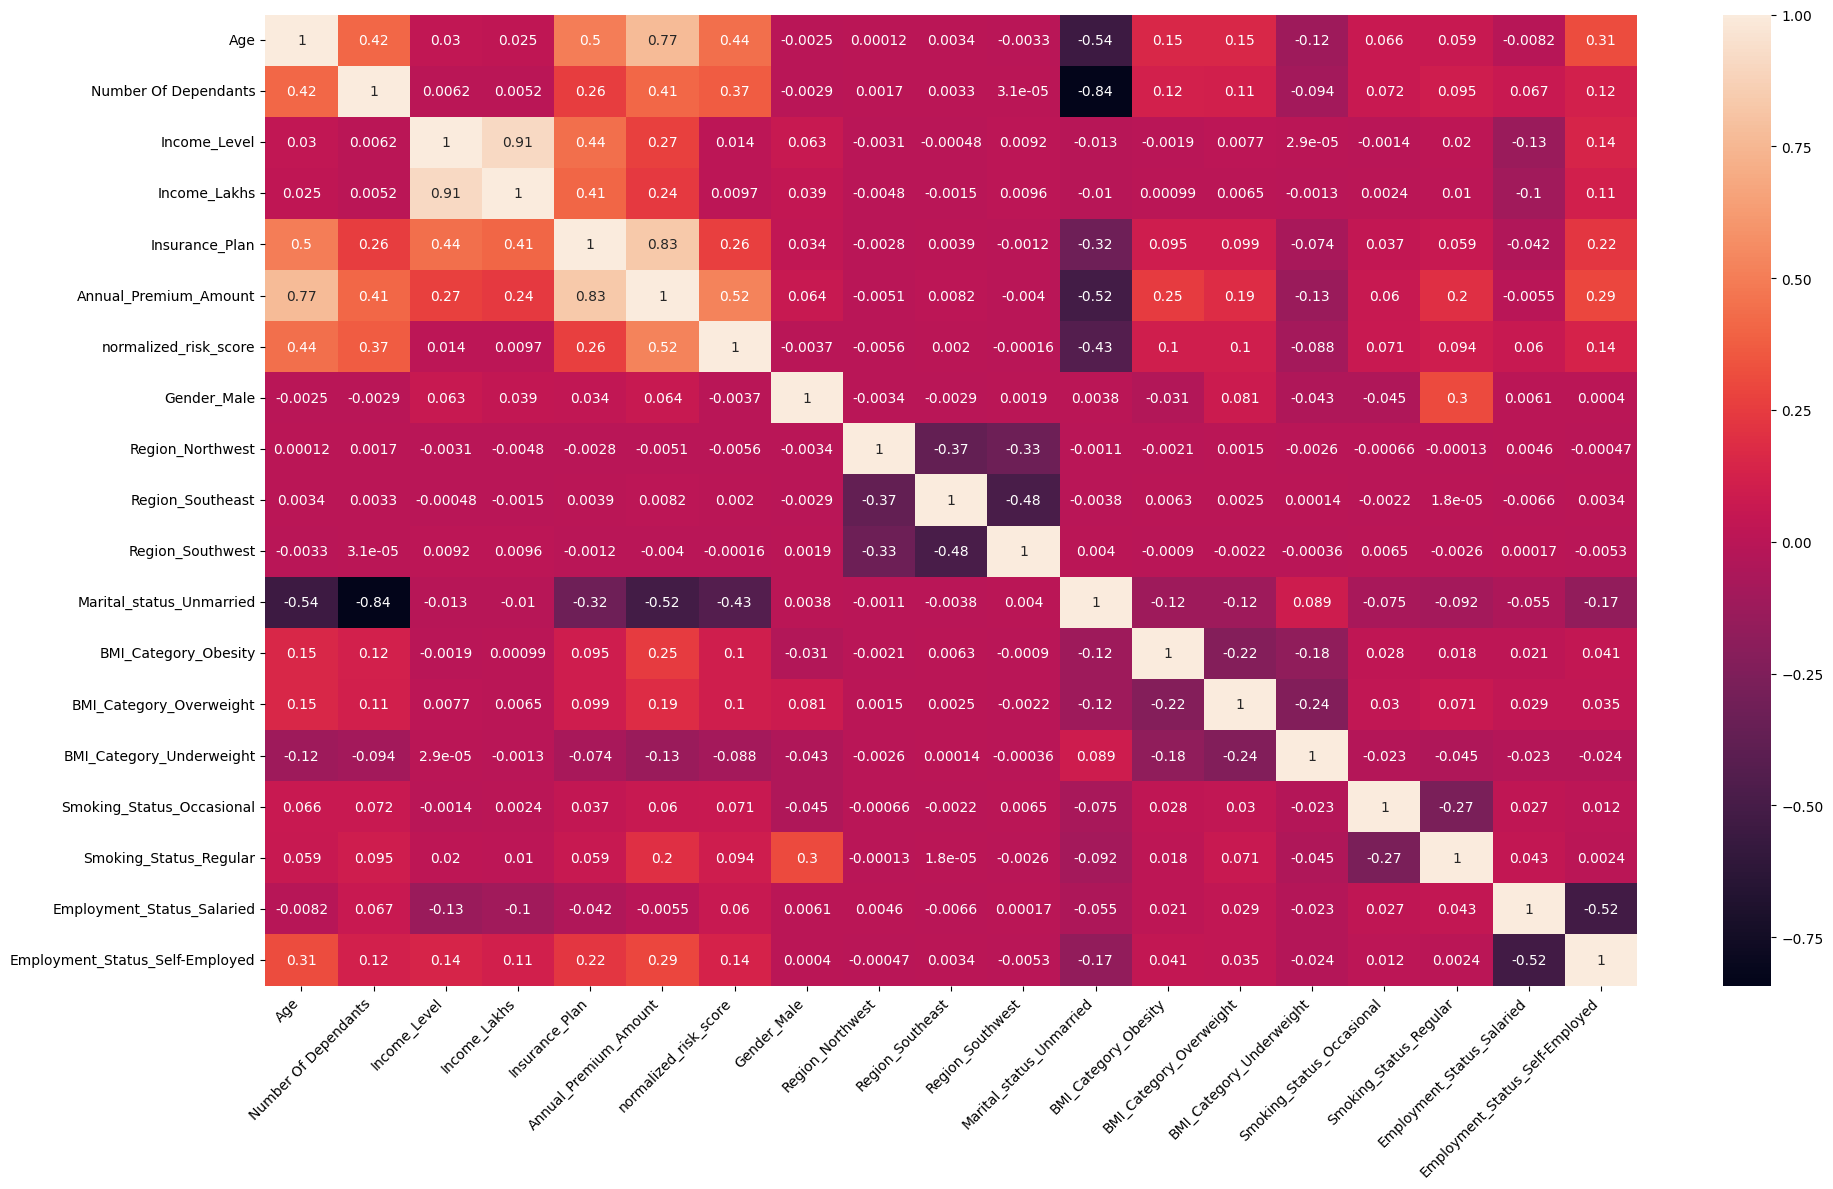

In [48]:
cm = df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
X = df4.drop('Annual_Premium_Amount', axis='columns')
y = df4['Annual_Premium_Amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['Age', 'Number Of Dependants', 'Income_Level', 'Income_Lakhs', 'Insurance_Plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,Age,Number Of Dependants,Income_Level,Income_Lakhs,Insurance_Plan,normalized_risk_score,Gender_Male,Region_Northwest,Region_Southeast,Region_Southwest,Marital_status_Unmarried,BMI_Category_Obesity,BMI_Category_Overweight,BMI_Category_Underweight,Smoking_Status_Occasional,Smoking_Status_Regular,Employment_Status_Salaried,Employment_Status_Self-Employed
count,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000,49832.000000
mean,0.303725,0.343490,0.364572,0.221758,0.396693,0.291845,0.549506,0.200895,0.350317,0.303058,0.513626,0.143241,0.231096,0.155342,0.138305,0.313674,0.419489,0.272014
std,0.253407,0.298422,0.348914,0.223674,0.392254,0.287471,0.497548,0.400674,0.477074,0.459585,0.499819,0.350322,0.421538,0.362234,0.345223,0.463990,0.493480,0.445002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.061224,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.153061,0.500000,0.357143,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.306122,0.500000,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [51]:
calculate_vif(X)

,Column,VIF
0,Age,2.034846
1,Number Of Dependants,3.488098
2,Income_Level,6.043926
3,Income_Lakhs,5.747447
4,Insurance_Plan,1.767832
5,normalized_risk_score,1.351819
6,Gender_Male,1.118788
7,Region_Northwest,1.901235
8,Region_Southeast,2.212122
9,Region_Southwest,2.147166


In [53]:
calculate_vif(X.drop('Income_Level', axis="columns"))

,Column,VIF
0,Age,2.021561
1,Number Of Dependants,3.488026
2,Income_Lakhs,1.281252
3,Insurance_Plan,1.700110
4,normalized_risk_score,1.351812
5,Gender_Male,1.114802
6,Region_Northwest,1.901086
7,Region_Southeast,2.211994
8,Region_Southwest,2.147021
9,Marital_status_Unmarried,4.131714


In [55]:
# we will drop income_lakhs due to high VIF value
X_reduced = X.drop('Income_Level', axis="columns")

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)
print("x train :" ,X_train.shape)
print("x test :" ,X_test.shape)
print("y train :" ,y_train.shape)
print("y test :" ,y_test.shape)


x train : (34882, 17)
x test : (14950, 17)
y train : (34882,)
y test : (14950,)


In [72]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

LINEAR REGRESSION

In [73]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [74]:
train_score = model_lr.score(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score,test_score

(0.9278822995473084, 0.9286701978166384)

In [75]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [76]:
y_pred=model_lr.predict(X_test)
mse_lr=mean_squared_error(y_test,y_pred)
rmse_lr=np.sqrt(mse_lr)
print("Linear Regression => MSE: ",mse_lr, "RMSE: ",rmse_lr)

Linear Regression => MSE:  5059828.064827221 RMSE:  2249.406158262047


In [77]:
X_test.shape

(14950, 17)

In [78]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([11189.870239,  -549.861713,  -428.599971, 12507.14939 ,
        4788.645802,   148.546202,    -1.115361,    72.707849,
          33.162548,  -857.685719,  3391.483441,  1658.108213,
         356.440897,   721.884163,  2246.179788,   150.108752,
         394.77714 ])

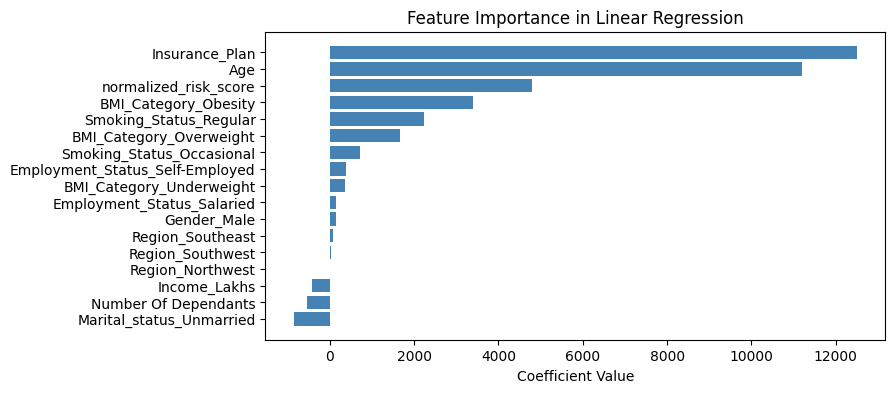

In [79]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

RIDGE REGRESSION

In [80]:
model_rg=Ridge(alpha=1)
model_rg.fit(X_train,y_train)

Ridge(alpha=1)

In [81]:
train_score=model_rg.score(X_train,y_train)
test_score=model_rg.score(X_test,y_test)
train_score,test_score

(0.9278822617220652, 0.9286684034985563)

In [82]:
y1_pred=model_rg.predict(X_test)
mse_rg=mean_squared_error(y_test,y1_pred)
rmse_rg=np.sqrt(mse_rg)
print("Ridge Regression => MSE: ",mse_rg, "RMSE: ",rmse_rg)

Ridge Regression => MSE:  5059955.346001589 RMSE:  2249.4344502566837


XGBoost

In [91]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [92]:
model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9783169031143188

In [93]:
y_pred=model_xgb.predict(X_test)
mse_xgb=mean_squared_error(y_test,y_pred)
rmse_xgb=np.sqrt(mse_xgb)
print("XGBoost Regression => MSE: ",mse_xgb, "RMSE: ",rmse_xgb)

XGBoost Regression => MSE:  1538103.125 RMSE:  1240.2028563908407


In [94]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9809630513191223)

In [95]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [97]:
best_model = random_search.best_estimator_

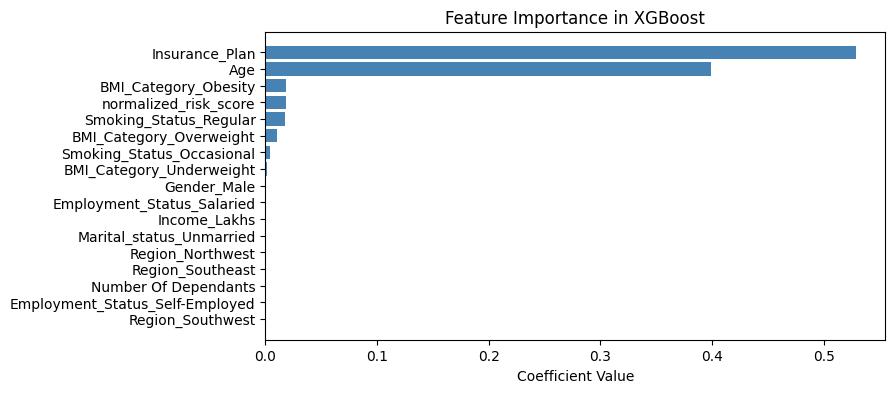

In [98]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [99]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
30610,21129,21444.070312,315.070312,1.491175
41599,7790,7253.015625,-536.984375,-6.893253
49761,20425,20887.998047,462.998047,2.266820
2553,33744,33158.746094,-585.253906,-1.734394
33002,10807,10398.905273,-408.094727,-3.776207


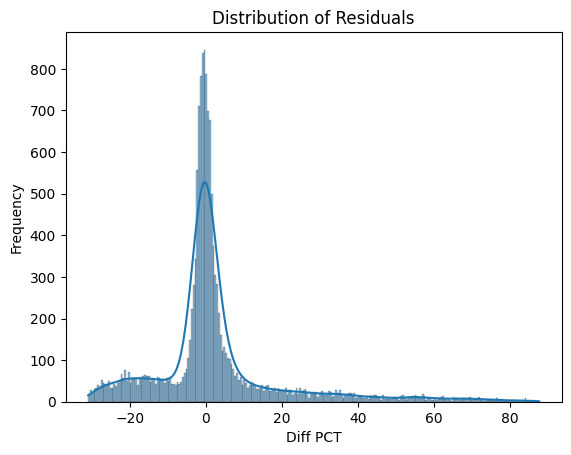

In [100]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [101]:
X_test.shape

(14950, 17)

In [102]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
26592,11667,13407.125977,1740.125977,14.914939
38780,7939,6577.757324,-1361.242676,-17.146274
27646,5361,7120.986816,1759.986816,32.829450
10744,5101,7101.881348,2000.881348,39.225276
26050,9991,7062.704102,-2928.295898,-29.309337


In [103]:
extreme_results_df.shape

(4500, 4)

In [104]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

30.100334448160535

In [105]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
29904,3503,6577.757324,3074.757324,87.774974
18922,3502,6558.522949,3056.522949,87.279353
23975,3520,6577.757324,3057.757324,86.868106
35305,3514,6547.260254,3033.260254,86.319301
9118,3536,6577.757324,3041.757324,86.022549
...,...,...,...,...
18347,4427,6653.250000,2226.250000,50.288005
11482,4583,6885.255859,2302.255859,50.234690
35523,4718,7084.932129,2366.932129,50.168125
33314,5583,8383.535156,2800.535156,50.161833


In [106]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,Age,Number Of Dependants,Income_Lakhs,Insurance_Plan,normalized_risk_score,Gender_Male,Region_Northwest,Region_Southeast,Region_Southwest,Marital_status_Unmarried,BMI_Category_Obesity,BMI_Category_Overweight,BMI_Category_Underweight,Smoking_Status_Occasional,Smoking_Status_Regular,Employment_Status_Salaried,Employment_Status_Self-Employed
26592,0.000000,0.2,0.173469,1.0,0.0,0,1,0,0,1,0,0,1,0,0,1,0
38780,0.074074,0.4,0.122449,0.0,0.0,0,0,1,0,1,0,0,0,0,0,0,1


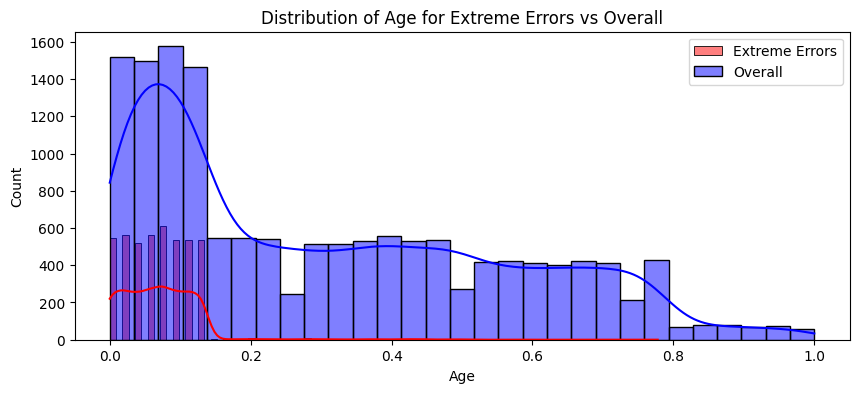

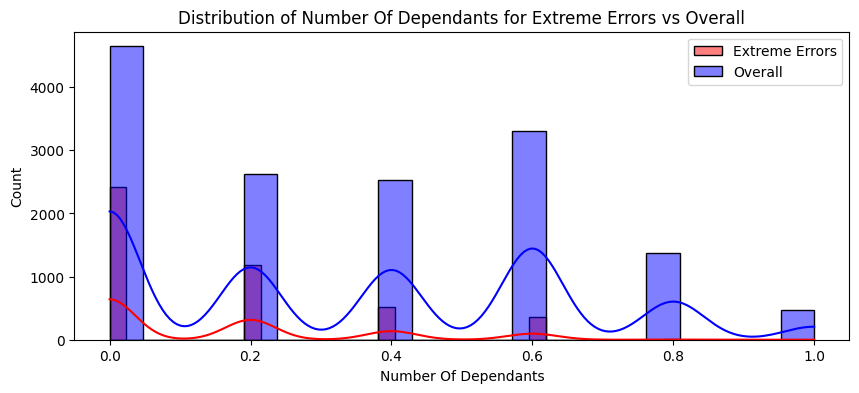

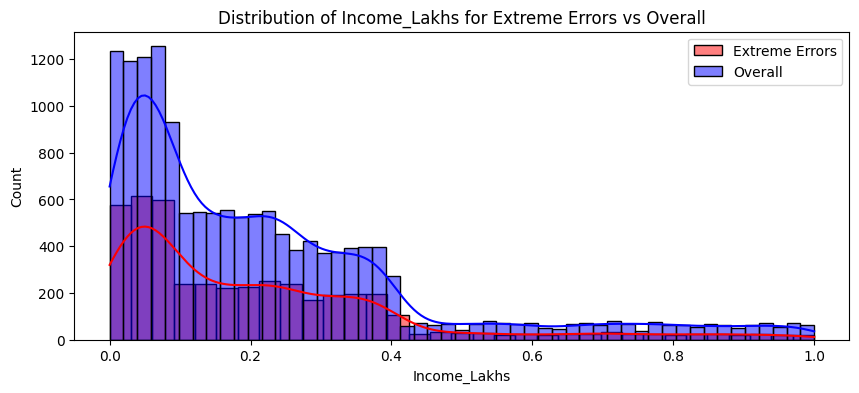

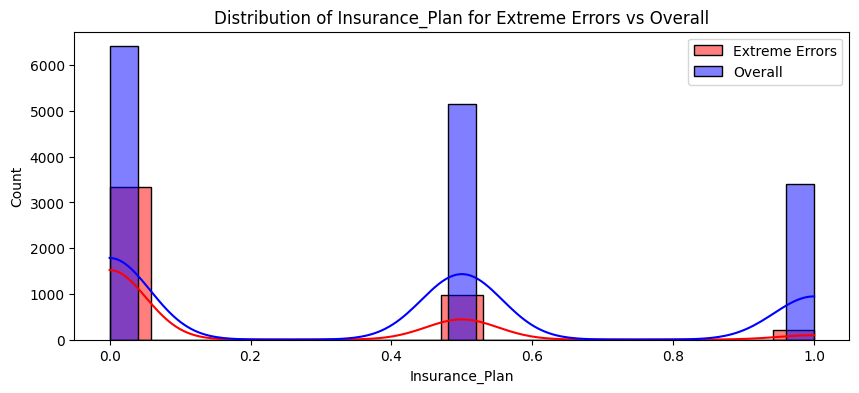

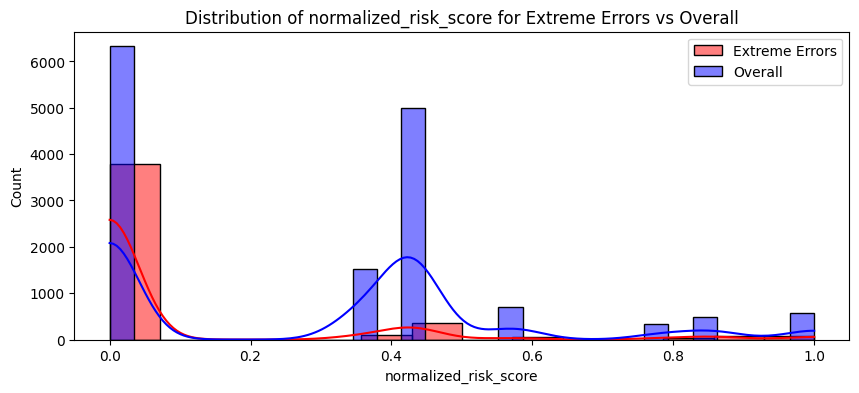

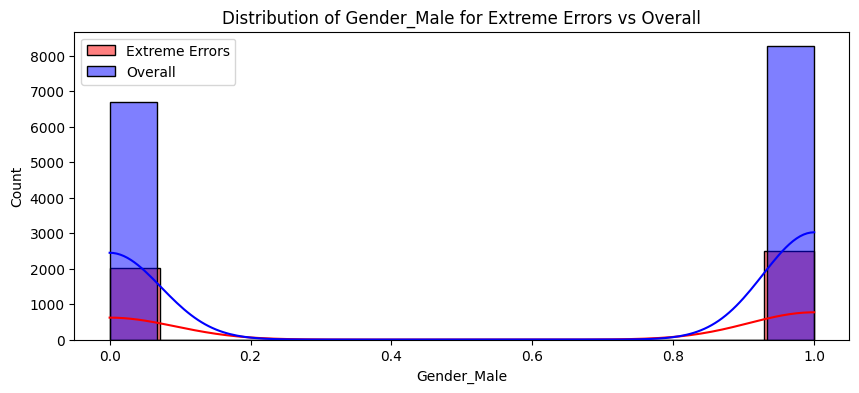

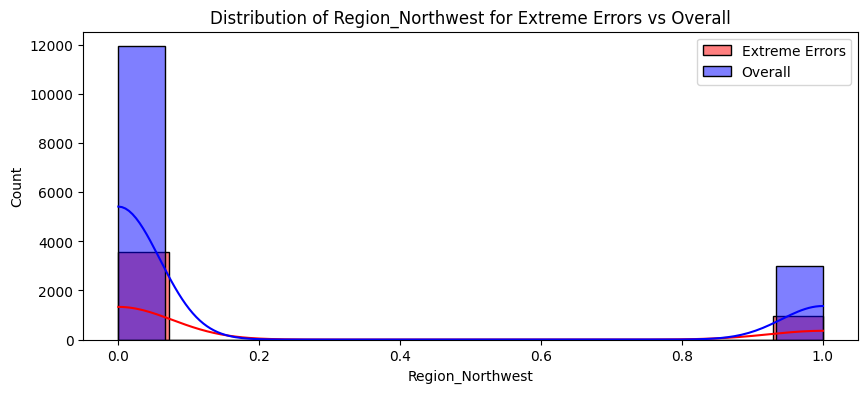

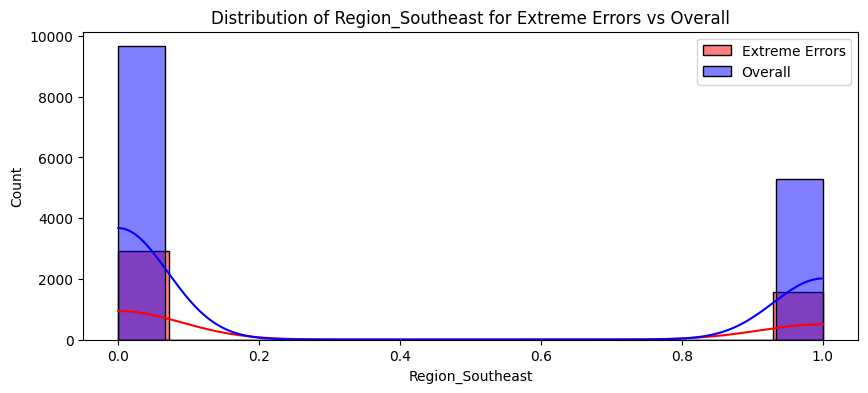

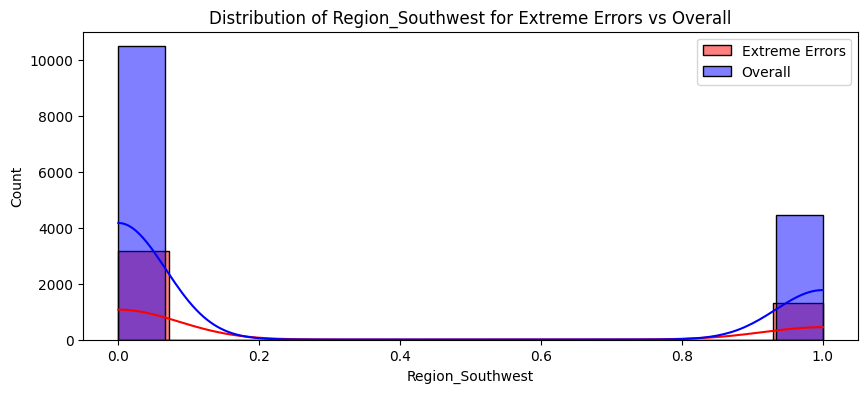

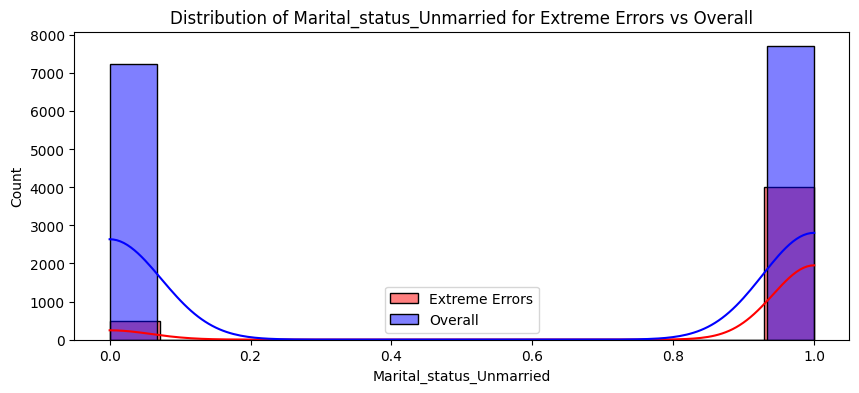

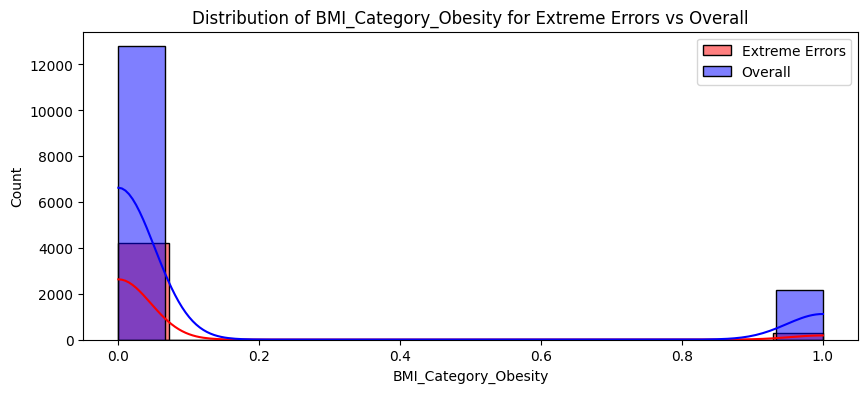

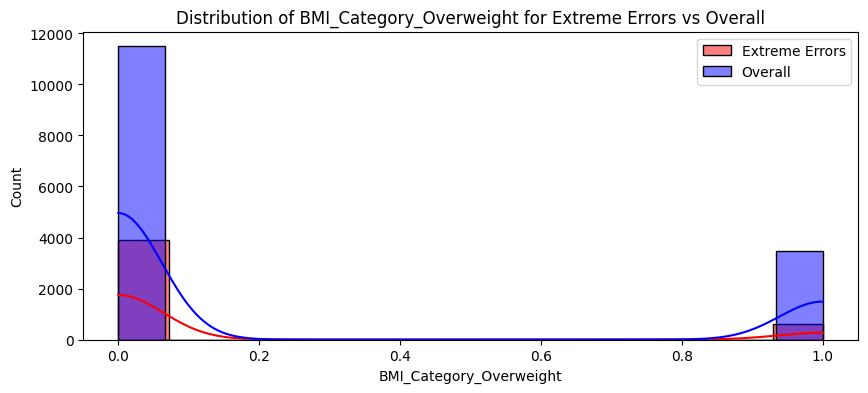

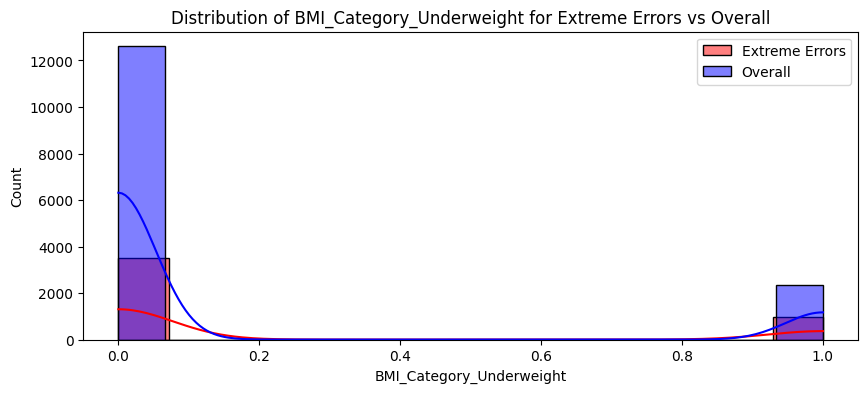

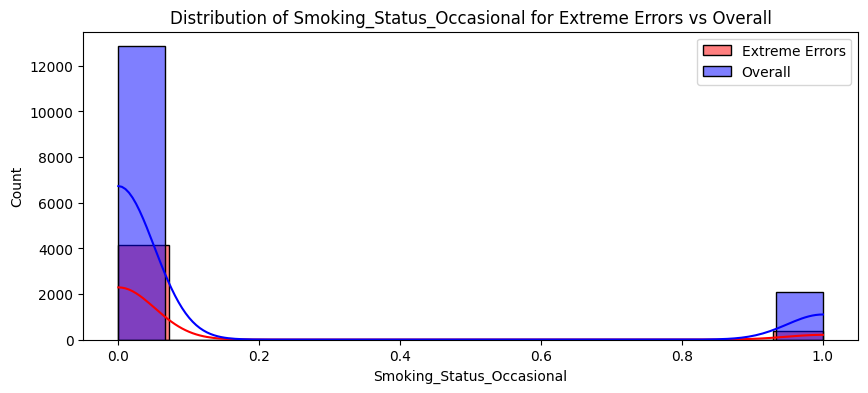

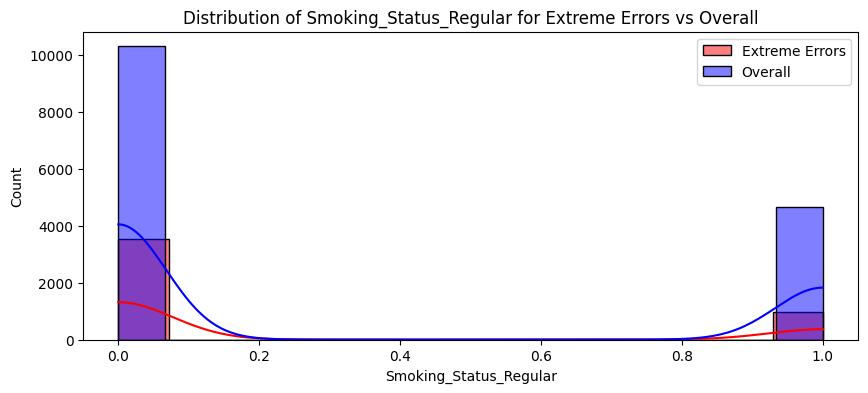

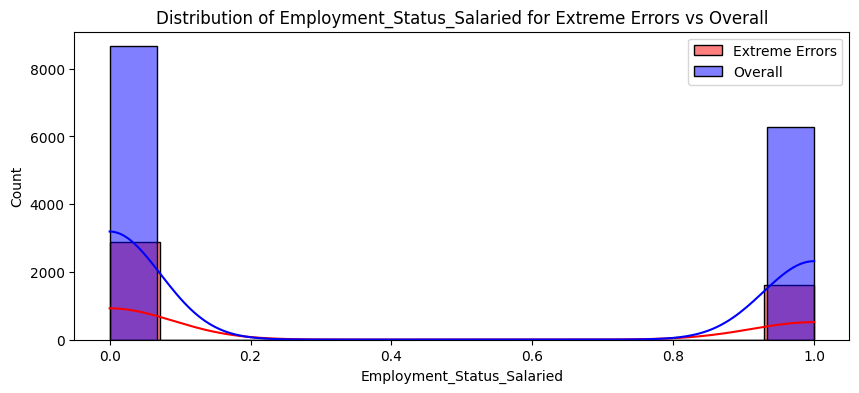

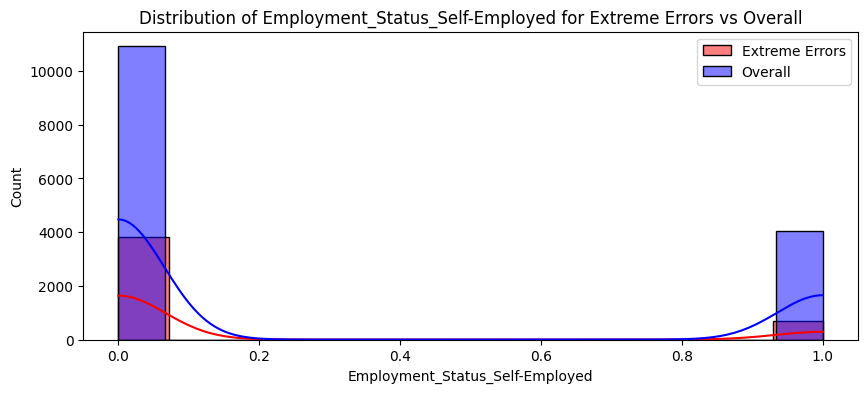

In [107]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [110]:
extreme_errors_df['Income_Level']=-1

In [111]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,Age,Number Of Dependants,Income_Level,Income_Lakhs,Insurance_Plan
0,18.0,1.0,-2.0,18.0,3.0
1,22.0,2.0,-2.0,13.0,1.0
2,22.0,1.0,-2.0,25.0,1.0
3,19.0,2.0,-2.0,9.0,1.0
4,18.0,0.0,-2.0,25.0,1.0


In [112]:
df_reversed.describe()

,Age,Number Of Dependants,Income_Level,Income_Lakhs,Insurance_Plan
count,4500.000000,4500.000000,4500.0,4500.000000,4500.000000
mean,21.795778,0.744222,-2.0,21.323778,1.306667
std,3.220341,0.966958,0.0,20.417455,0.552390
min,18.000000,0.000000,-2.0,1.000000,1.000000
25%,20.000000,0.000000,-2.0,6.000000,1.000000
50%,22.000000,0.000000,-2.0,15.000000,1.000000
75%,24.000000,1.000000,-2.0,31.000000,2.000000
max,60.000000,5.000000,-2.0,99.000000,3.000000


<Axes: xlabel='Age', ylabel='Count'>

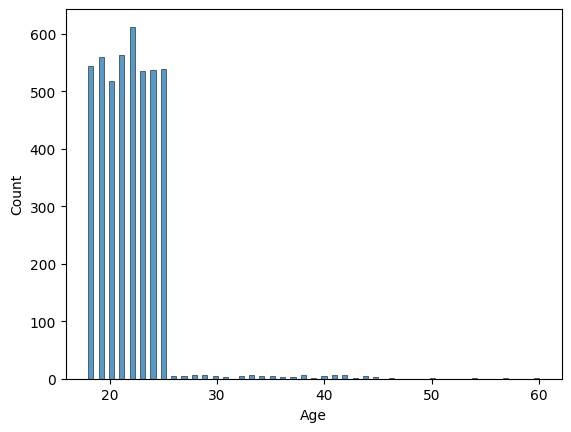

In [114]:
sns.histplot(df_reversed.Age)